In [10]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

from models import PINN
from utils import derivative, get_device
from plot import *

In [11]:
import torch 
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt

device = get_device()

# creating the model

In [12]:
model = PINN(input_dim=2, hidden_dim=64, output_dim=1, num_layers=4)
if 'device' in globals():
    model = model.to(device)

In [13]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# describind pde

## intern points
#### minimize ut​−Duxx​=0

In [14]:
Nf = 5000

t_f = torch.rand(Nf, 1, device=device, requires_grad=True)
x_f = torch.rand(Nf, 1, device=device, requires_grad=True)

## boundary conditions

## x= 0
#### u(t,0) = 1

In [15]:
Nb = 1000
t_b1 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b1 = torch.zeros(Nb, 1, device=device, requires_grad=True)
u_b1_true = torch.ones(Nb,1, device=device) 

#### u(t,1) = 1

In [16]:
t_b2 = torch.rand(Nb,1, device=device, requires_grad=True)
x_b2 = torch.ones(Nb,1, device=device, requires_grad=True)
u_b2_true = torch.ones(Nb,1, device=device,)

## initial conditions
### u(0,x) = 0

In [17]:
Ni = 2000
t_i = torch.zeros(Ni, 1, device=device, requires_grad=True)
x_i = torch.rand(Ni,1, device=device, requires_grad=True)
u_i_true = torch.zeros(Ni,1, device=device,)

# Training

In [27]:
a = 0.1
epochs = 8000

for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE

    u_f = model(t_f, x_f)
    u_t = derivative(u_f, t_f)
    u_x = derivative(u_f, x_f)
    u_xx = derivative(u_x, x_f)

    # equation residual
    loss_pde = torch.mean((u_t - a * u_xx)**2)

    # bc conditions
    u_b1 = model(t_b1, x_b1)
    u_b2 = model(t_b2, x_b2)

    # bc residual
    loss_bc = (
        torch.mean((u_b1 - u_b1_true)**2)
        +
        torch.mean((u_b2 - u_b2_true)**2)
    )

    # initial conditions
    u_i = model(t_i, x_i)

    # initial residual
    loss_ic = torch.mean((u_i - u_i_true)**2)

    # TOTAL LOSS
    loss = (loss_pde + loss_bc + loss_ic)

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss_pde.item(), loss_bc.item(), loss_ic.item(), loss.item())

0 1.2753223180770874 0.0035488249268382788 0.002151170978322625 1.281022310256958
1000 0.0017709475941956043 0.008231783285737038 0.006740206852555275 0.01674293726682663
2000 0.001079502864740789 0.004692419432103634 0.004116574302315712 0.00988849624991417
3000 0.001321602612733841 0.004078334197402 0.0033464650623500347 0.008746402338147163
4000 0.0004638414247892797 0.003499557264149189 0.002867064205929637 0.00683046318590641
5000 0.0004040385247208178 0.0032727569341659546 0.0022837440483272076 0.005960539449006319
6000 0.000269126845523715 0.0030028712935745716 0.002026264788582921 0.005298262927681208
7000 0.004157749004662037 0.003520159050822258 0.0016686881426721811 0.009346595965325832


# Vizualizing
### creating the space

In [19]:
nx = 200
nt = 100

x = torch.linspace(0,1,nx)
t = torch.linspace(0,1,nt)

X, T = torch.meshgrid(t,x,indexing='ij')

x_test = X.reshape(-1,1).to(device)
t_test = T.reshape(-1,1).to(device)

with torch.no_grad():
    U = model(t_test, x_test)

U = U.reshape(nt,nx).cpu()

## graph

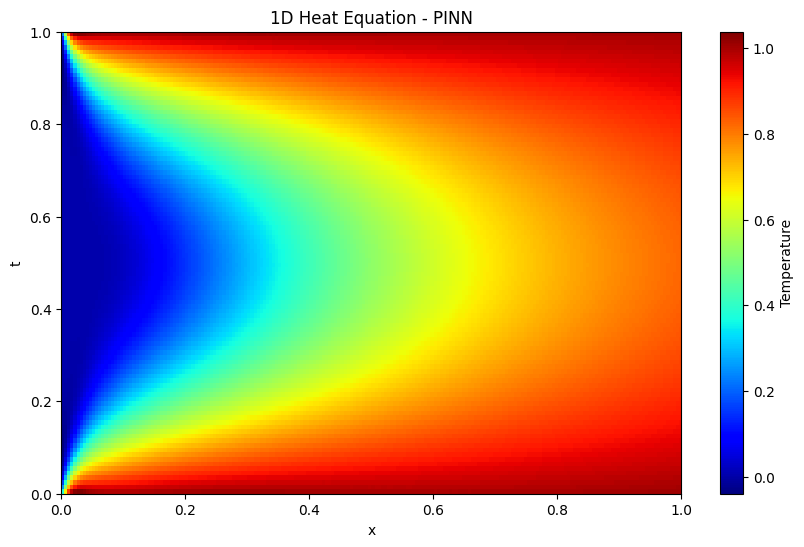

In [20]:
plot_1d_heatmap(U, filename='assets/edges_at_1deg/spatiotemporal_heatmap.png')

# 3D

In [21]:
from mpl_toolkits.mplot3d import Axes3D

In [22]:
nx = 100
nt = 100

x = torch.linspace(0,1,nx)

t = torch.linspace(0,1,nt)

T, X = torch.meshgrid(
    t,
    x,
    indexing='ij'
)

In [23]:
x_test = X.reshape(-1,1).to(device)

t_test = T.reshape(-1,1).to(device)

In [24]:
with torch.no_grad():

    U = model(
        t_test,
        x_test
    )

In [25]:
U = U.reshape(nt,nx).cpu()

U = U.numpy()

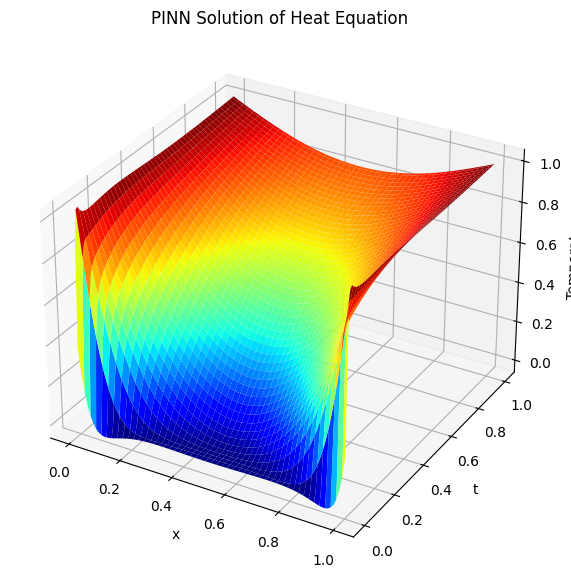

In [28]:
plot_1d_surface(X.numpy(), T.numpy(), U, filename='assets/edges_at_1deg/spatiotemporal_surface.png')